# ICG for the plate-hole system

This notebook applies the `system_303_solver_v2` workflow to `system_plate/plate_hole_data.pkl`.
It loads the plate-system matrix `K`, vector `F`, reference solution `U`, and both initial boxes `B0_1` and `B0_2`, expands `K` to a dense array once, solves with the full symmetric matrix `K + K.T - diag(diag(K))`, then saves all generated arrays and GIFs in the same folder as the pickle file.


In [1]:
from pathlib import Path
import os
import pickle
import tempfile

base_dir = Path("system_plate")
pickle_path = base_dir / "plate_hole_data.pkl"
base_dir.mkdir(parents=True, exist_ok=True)

# Keep matplotlib cache out of the repository while avoiding user-level write requirements.
matplotlib_cache_dir = Path(tempfile.gettempdir()) / "cg_hyperbox_matplotlib_cache"
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_cache_dir))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, FileLink, display
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.linalg import qr
from scipy.optimize import linprog
from scipy.sparse.linalg import LinearOperator, cg, eigsh

with pickle_path.open("rb") as file:
    K, F, U, B0_1, B0_2 = pickle.load(file)

A_loaded = K.toarray() if hasattr(K, "toarray") else np.asarray(K, dtype=float)
A_loaded = np.asarray(A_loaded, dtype=float)
A = A_loaded.copy()
A += A_loaded.T
A[np.diag_indices_from(A)] = A_loaded.diagonal()
b = np.asarray(F, dtype=float).reshape(-1)
x_reference = np.asarray(U, dtype=float).reshape(-1)
boxes = {
    "B0_1": np.asarray(B0_1, dtype=float),
    "B0_2": np.asarray(B0_2, dtype=float),
}

n = b.size
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
if x_reference.shape != (n,):
    raise ValueError(f"Expected U to have shape {(n,)}, got {x_reference.shape}.")

for box_name, box in boxes.items():
    if box.shape != (n, 2):
        raise ValueError(f"{box_name} should have shape {(n, 2)}, got {box.shape}.")
    if np.any(box[:, 0] > box[:, 1]):
        raise ValueError(f"{box_name} has lower bounds above upper bounds.")

print("A_loaded shape:", A_loaded.shape)
print("A_loaded nonzeros:", np.count_nonzero(A_loaded))
print("A shape after symmetrization:", A.shape)
print("A nonzeros after symmetrization:", np.count_nonzero(A))
print("b shape:", b.shape)
print("U shape:", x_reference.shape)
for box_name, box in boxes.items():
    contains_reference = np.all((box[:, 0] <= x_reference) & (x_reference <= box[:, 1]))
    print(f"{box_name} shape: {box.shape}, contains U: {contains_reference}")



A_loaded shape: (21570, 21570)
A_loaded nonzeros: 340779
A shape after symmetrization: (21570, 21570)
A nonzeros after symmetrization: 659988
b shape: (21570,)
U shape: (21570,)
B0_1 shape: (21570, 2), contains U: False
B0_2 shape: (21570, 2), contains U: True


loaded symmetry error: 200699.21619962758
symmetrized symmetry error: 0.0


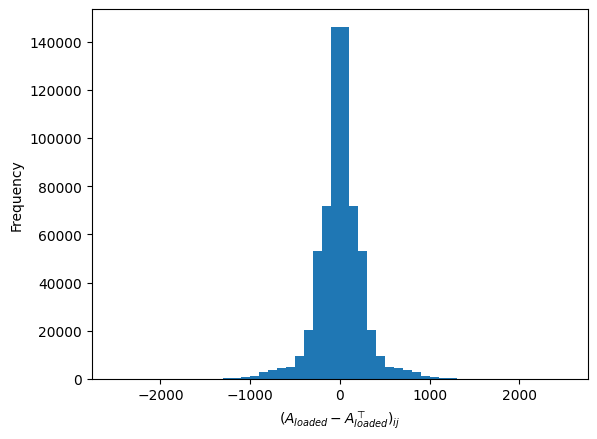

In [2]:
def off_diagonal_symmetry_diffs(matrix):
    rows, cols = np.nonzero(matrix)
    off_diagonal = rows != cols
    rows = rows[off_diagonal]
    cols = cols[off_diagonal]
    if rows.size == 0:
        return np.array([], dtype=float)

    pairs = np.column_stack((np.minimum(rows, cols), np.maximum(rows, cols)))
    pairs = np.unique(pairs, axis=0)
    return matrix[pairs[:, 0], pairs[:, 1]] - matrix[pairs[:, 1], pairs[:, 0]]


loaded_pair_diffs = off_diagonal_symmetry_diffs(A_loaded)
symmetrized_pair_diffs = off_diagonal_symmetry_diffs(A)
loaded_symmetry_error = np.sqrt(2.0 * np.sum(loaded_pair_diffs**2))
symmetrized_symmetry_error = np.sqrt(2.0 * np.sum(symmetrized_pair_diffs**2))
print("loaded symmetry error:", loaded_symmetry_error)
print("symmetrized symmetry error:", symmetrized_symmetry_error)

diff_values = loaded_pair_diffs[loaded_pair_diffs != 0]
if diff_values.size:
    plt.hist(np.concatenate((diff_values, -diff_values)), bins=50)
else:
    plt.hist([0.0], bins=1)
plt.xlabel(r"$(A_{loaded}-A_{loaded}^\top)_{ij}$")
plt.ylabel("Frequency")
plt.show()




## Preconditioning

Use Jacobi scaling with `scale = sqrt(diag(A))`. The CG solve is performed in the transformed variable `y = scale * x`, so `x = y / scale`.


In [3]:
diag_A = A.diagonal()
if np.any(diag_A <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diag_A)
inv_scale = 1.0 / scale
b_hat = inv_scale * b


def ahat_matvec(y):
    y = np.asarray(y, dtype=float)
    return inv_scale * (A @ (inv_scale * y))


A_hat = LinearOperator(A.shape, matvec=ahat_matvec, dtype=float)
y_reference = scale * x_reference

print("scale shape:", scale.shape)
print("b_hat shape:", b_hat.shape)
print("reference residual norm in original system:", np.linalg.norm(b - A @ x_reference))
print("reference residual norm in scaled system:", np.linalg.norm(b_hat - A_hat @ y_reference))

# Eigenvalue estimates are useful but expensive for this 21k system.
RUN_EIGEN_ESTIMATE = False
if RUN_EIGEN_ESTIMATE:
    lambda_min_A = eigsh(A, k=1, which="SA", return_eigenvectors=False, tol=1e-4)[0]
    lambda_max_A = eigsh(A, k=1, which="LA", return_eigenvectors=False, tol=1e-4)[0]
    lambda_min_A_hat = eigsh(A_hat, k=1, which="SA", return_eigenvectors=False, tol=1e-4)[0]
    lambda_max_A_hat = eigsh(A_hat, k=1, which="LA", return_eigenvectors=False, tol=1e-4)[0]

    print("A:")
    print(f"  smallest eigenvalue estimate: {lambda_min_A:.16e}")
    print(f"  biggest eigenvalue estimate:  {lambda_max_A:.16e}")
    print(f"  condition estimate:           {lambda_max_A / lambda_min_A:.16e}")

    print("\nA_hat:")
    print(f"  smallest eigenvalue estimate: {lambda_min_A_hat:.16e}")
    print(f"  biggest eigenvalue estimate:  {lambda_max_A_hat:.16e}")
    print(f"  condition estimate:           {lambda_max_A_hat / lambda_min_A_hat:.16e}")



scale shape: (21570,)
b_hat shape: (21570,)
reference residual norm in original system: 33.792556690764485
reference residual norm in scaled system: 1.018700441259076


## SciPy CG baseline


SciPy CG info: 0 (0 means converged)
SciPy CG iterations recorded: 1988
SciPy CG final residual norm: 1.5241772376609768e-10
relative error against U: 1310.3859262486064
saved solution to: system_plate/x_scipy_cg_plate.npy


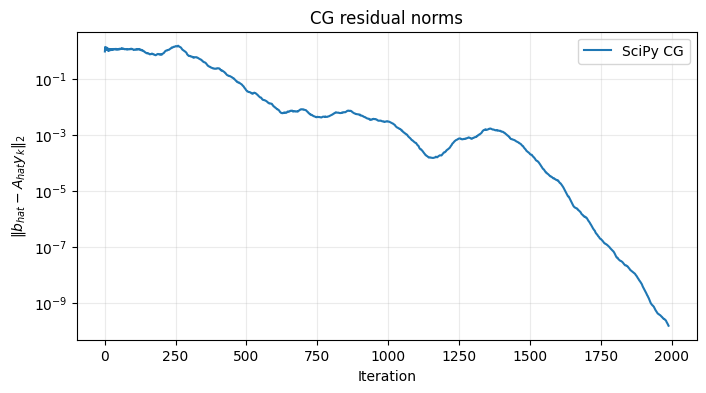

In [4]:
SOLVE_RTOL = 1e-10
SOLVE_ATOL = 0.0
SOLVE_MAXITER = 10_000

scipy_residual_norms = []


def record_scipy_residual(yk):
    scipy_residual_norms.append(np.linalg.norm(b_hat - A_hat @ yk))


y_scipy_cg, scipy_cg_info = cg(
    A_hat,
    b_hat,
    rtol=SOLVE_RTOL,
    atol=SOLVE_ATOL,
    maxiter=SOLVE_MAXITER,
    callback=record_scipy_residual,
)
x_scipy_cg = y_scipy_cg / scale

np.save(base_dir / "x_scipy_cg_plate.npy", x_scipy_cg)
np.save(base_dir / "scipy_residual_norms_plate.npy", np.asarray(scipy_residual_norms))

print("SciPy CG info:", scipy_cg_info, "(0 means converged)")
print("SciPy CG iterations recorded:", len(scipy_residual_norms))
if scipy_residual_norms:
    print("SciPy CG final residual norm:", scipy_residual_norms[-1])
print("relative error against U:", np.linalg.norm(x_scipy_cg - x_reference) / np.linalg.norm(x_reference))
print("saved solution to:", base_dir / "x_scipy_cg_plate.npy")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} y_k\|_2$")
ax.set_title("CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Custom CG with recorded constraints

The custom CG run records the search-direction constraints used by the box minimization. `DIRECTION_MAXITER` defaults to 500 so the generated GIFs match the iteration range used in the v2 visualizations; increase it if you need later snapshots.


In [5]:
def cg_with_direction_callback(
    A,
    b,
    x0=None,
    rtol=1e-8,
    atol=0.0,
    maxiter=None,
    M=None,
    callback=None,
    direction_callback=None,
):
    b = np.asarray(b)
    n = b.shape[0]
    x = np.zeros_like(b) if x0 is None else np.array(x0, dtype=b.dtype, copy=True)

    def matvec(v):
        if callable(A):
            return np.asarray(A(v))
        if hasattr(A, "matvec"):
            return np.asarray(A.matvec(v))
        return np.asarray(A @ v)

    def psolve(v):
        if M is None:
            return v.copy()
        if callable(M):
            return np.asarray(M(v))
        if hasattr(M, "matvec"):
            return np.asarray(M.matvec(v))
        return np.asarray(M @ v)

    if maxiter is None:
        maxiter = n * 10

    bnrm2 = np.linalg.norm(b)
    atol_threshold = max(float(atol), float(rtol) * bnrm2)

    r = b - matvec(x) if x0 is not None else b.copy()
    if np.linalg.norm(r) < atol_threshold:
        return x, 0

    rho_prev = None
    p = None

    for k in range(maxiter):
        z = psolve(r)
        rho_cur = np.dot(r, z)

        if k > 0:
            beta = rho_cur / rho_prev
            p = z + beta * p
        else:
            p = z.copy()

        q = matvec(p)
        if direction_callback is not None:
            direction_callback(k, x.copy(), r.copy(), p.copy(), q.copy())

        alpha = rho_cur / np.dot(p, q)
        x += alpha * p
        r -= alpha * q

        if callback is not None:
            callback(x.copy())

        if np.linalg.norm(r) < atol_threshold:
            return x, 0

        rho_prev = rho_cur

    return x, maxiter


Custom CG info: 500 (0 means converged)
Custom CG iterations recorded: 500
Custom CG final residual norm: 0.03873881857053448
Custom relative error against U: 1309.8748653236107
Q_cg shape: (500, 21570)
c_cg shape: (500,)


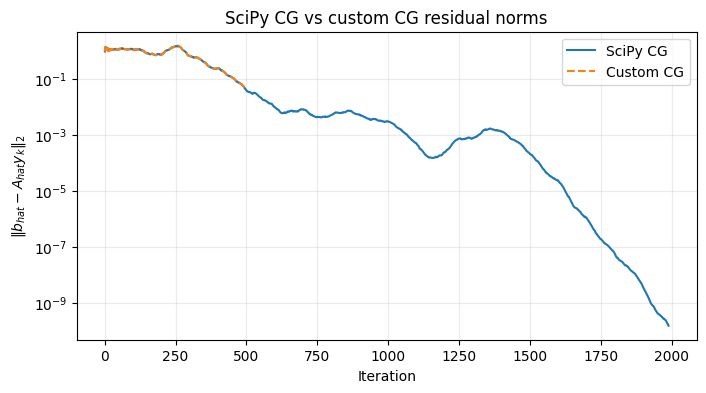

In [6]:
DIRECTION_RTOL = SOLVE_RTOL
DIRECTION_ATOL = SOLVE_ATOL
DIRECTION_MAXITER = 500
SAVE_CG_CONSTRAINTS = True

custom_residual_norms = []
q_list = []
c_list = []


def record_custom_residual(yk):
    custom_residual_norms.append(np.linalg.norm(b_hat - A_hat @ yk))


def record_direction(k, y, r, p, q):
    q_list.append(q.astype(float, copy=True))
    c_list.append(float(np.dot(p, b_hat)))


y_custom_cg, custom_cg_info = cg_with_direction_callback(
    A_hat,
    b_hat,
    rtol=DIRECTION_RTOL,
    atol=DIRECTION_ATOL,
    maxiter=DIRECTION_MAXITER,
    callback=record_custom_residual,
    direction_callback=record_direction,
)
x_custom_cg = y_custom_cg / scale

Q_cg = np.vstack(q_list)
c_cg = np.asarray(c_list)

np.save(base_dir / "custom_residual_norms_plate.npy", np.asarray(custom_residual_norms))
if SAVE_CG_CONSTRAINTS:
    np.save(base_dir / "Q_cg_plate.npy", Q_cg)
    np.save(base_dir / "c_cg_plate.npy", c_cg)

print("Custom CG info:", custom_cg_info, "(0 means converged)")
print("Custom CG iterations recorded:", len(custom_residual_norms))
if custom_residual_norms:
    print("Custom CG final residual norm:", custom_residual_norms[-1])
print("Custom relative error against U:", np.linalg.norm(x_custom_cg - x_reference) / np.linalg.norm(x_reference))
print("Q_cg shape:", Q_cg.shape)
print("c_cg shape:", c_cg.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.semilogy(
    range(1, len(custom_residual_norms) + 1),
    custom_residual_norms,
    "--",
    label="Custom CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} y_k\|_2$")
ax.set_title("SciPy CG vs custom CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Independent constraints


In [11]:
row_norms = np.linalg.norm(Q_cg, axis=1)
nonzero = row_norms > 0

Qn_all = Q_cg[nonzero] / row_norms[nonzero, None]
cn_all = c_cg[nonzero] / row_norms[nonzero]
constraint_iterations_all = np.flatnonzero(nonzero) + 1

QT = Qn_all.T
_, R, piv = qr(QT, pivoting=True, mode="economic")

diag_R = np.abs(np.diag(R))
tol = 1e-10 * diag_R[0] if diag_R.size else 0.0
rank = int(np.sum(diag_R > tol))
selected = piv[:rank]

Q_ind = Qn_all[selected]
c_ind = cn_all[selected]

np.save(base_dir / "Q_ind_plate.npy", Q_ind)
np.save(base_dir / "c_ind_plate.npy", c_ind)
np.save(base_dir / "constraint_iterations_all_plate.npy", constraint_iterations_all)

print("Selected rank:", rank)
print("Q_ind shape:", Q_ind.shape)
print("c_ind shape:", c_ind.shape)


Selected rank: 479
Q_ind shape: (479, 21570)
c_ind shape: (479,)


In [12]:
constraint_residual_ind = Q_ind @ y_custom_cg - c_ind
observed_tau = np.max(np.abs(constraint_residual_ind)) if constraint_residual_ind.size else 0.0
tau = max(10.0 * observed_tau, 1e-10)

print("max selected normalized residual:", observed_tau)
print("norm selected normalized residual:", np.linalg.norm(constraint_residual_ind))
print("Using tau:", tau)


max selected normalized residual: 0.0014456274900509491
norm selected normalized residual: 0.00869396187769164
Using tau: 0.014456274900509491


## Tracked box minimization snapshots

The plate system is much larger than `system_303`, so the default animation data is computed for an evenly sampled subset of plate displacement coordinates. Increase `MAX_TRACKED_COORDINATES`, `SNAPSHOT_STEP`, or `DIRECTION_MAXITER` if you need denser animation data.


In [13]:
def independent_normalized_constraints_through_iteration(iteration, qr_tol=1e-10):
    mask = constraint_iterations_all <= iteration
    Qn_iter = Qn_all[mask]
    cn_iter = cn_all[mask]

    if Qn_iter.size == 0:
        return Qn_iter.reshape(0, n), cn_iter

    _, R_iter, piv_iter = qr(Qn_iter.T, pivoting=True, mode="economic")
    diag_R_iter = np.abs(np.diag(R_iter))

    if diag_R_iter.size == 0 or diag_R_iter[0] == 0:
        return Qn_iter[:0], cn_iter[:0]

    rank_iter = int(np.sum(diag_R_iter > qr_tol * diag_R_iter[0]))
    selected_iter = piv_iter[:rank_iter]

    return Qn_iter[selected_iter], cn_iter[selected_iter]


def _linprog_with_fallback(obj, A_ub, b_ub, bounds, label, coordinate):
    attempts = [
        ("highs", None),
        ("highs-ds", None),
        ("highs-ipm", None),
        ("highs", {"presolve": False}),
        ("highs-ds", {"presolve": False}),
    ]
    last_res = None

    for method, options in attempts:
        res = linprog(
            obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=method,
            options=options,
        )
        if res.success and np.isfinite(res.fun):
            return res
        last_res = res

    raise RuntimeError(
        f"{label} LP failed at coordinate {coordinate}: {last_res.message}"
    )


def coordinate_bounds_for_indices_from_relaxed_constraints_unit_box(
    Q,
    c,
    ell,
    u,
    tau,
    coordinate_indices,
):
    ell = np.asarray(ell, dtype=float)
    u = np.asarray(u, dtype=float)
    coordinate_indices = np.asarray(coordinate_indices, dtype=int)
    widths = u - ell
    free = widths > 0

    tracked_lower = ell[coordinate_indices].copy()
    tracked_upper = u[coordinate_indices].copy()

    if len(c) == 0 or not np.any(free):
        return np.column_stack([tracked_lower, tracked_upper])

    free_indices = np.flatnonzero(free)
    free_lookup = {int(coordinate): local_i for local_i, coordinate in enumerate(free_indices)}

    constant_part = Q @ ell
    Q_scaled = Q[:, free] * widths[free][None, :]

    A_ub = np.vstack([Q_scaled, -Q_scaled])
    b_ub = np.concatenate([
        c + tau - constant_part,
        -c + tau + constant_part,
    ])

    row_norms = np.linalg.norm(A_ub, axis=1)
    zero_rows = row_norms == 0
    if np.any(zero_rows & (b_ub < -1e-12)):
        raise RuntimeError("Infeasible zero-row constraint in snapshot LP.")

    keep_rows = row_norms > 0
    A_ub = A_ub[keep_rows] / row_norms[keep_rows, None]
    b_ub = b_ub[keep_rows] / row_norms[keep_rows]

    bounds = [(0.0, 1.0)] * len(free_indices)

    for out_i, coordinate in enumerate(coordinate_indices):
        local_i = free_lookup.get(int(coordinate))
        if local_i is None:
            continue

        obj = np.zeros(len(free_indices))
        obj[local_i] = 1.0

        res_min = _linprog_with_fallback(
            obj, A_ub, b_ub, bounds, "Min", int(coordinate)
        )
        res_max = _linprog_with_fallback(
            -obj, A_ub, b_ub, bounds, "Max", int(coordinate)
        )

        z_min = np.clip(res_min.fun, 0.0, 1.0)
        z_max = np.clip(-res_max.fun, 0.0, 1.0)
        tracked_lower[out_i] = ell[coordinate] + widths[coordinate] * z_min
        tracked_upper[out_i] = ell[coordinate] + widths[coordinate] * z_max

    return np.column_stack([tracked_lower, tracked_upper])


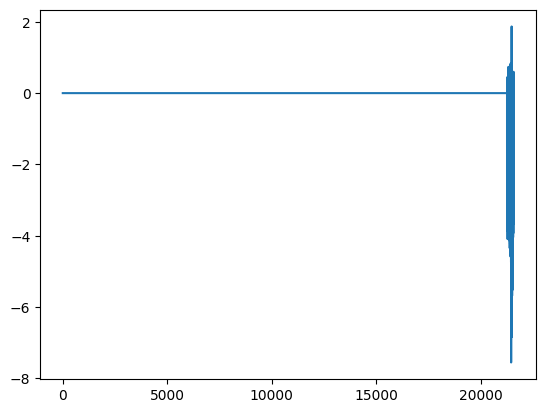

In [22]:
plt.plot(A@U - b)

In [14]:
DOFS_PER_NODE = 2
TRACK_COMPONENT_REMAINDER = 1
MAX_TRACKED_COORDINATES = 120
SNAPSHOT_STEP = 5
REUSE_SAVED_SNAPSHOTS = False
EXPAND_BOXES_TO_CONTAIN_REFERENCE = True


def choose_tracked_indices(n, dofs_per_node=2, remainder=1, max_count=120):
    candidates = np.flatnonzero(np.arange(n) % dofs_per_node == remainder)
    if len(candidates) == 0:
        candidates = np.arange(n)
    if len(candidates) <= max_count:
        return candidates
    positions = np.linspace(0, len(candidates) - 1, max_count).round().astype(int)
    return candidates[np.unique(positions)]


def snapshot_paths_for_box(box_name):
    return {
        "tracked_boxes": base_dir / f"{box_name}_minimized_tracked_boxes_by_iteration.npy",
        "iterations": base_dir / f"{box_name}_box_snapshot_iterations.npy",
        "selected_counts": base_dir / f"{box_name}_selected_constraint_counts.npy",
        "tracked_indices": base_dir / f"{box_name}_tracked_coordinate_indices.npy",
        "initial_box": base_dir / f"{box_name}_initial_tracked_box.npy",
    }


def load_saved_box_result(box_name, ell0, u0):
    paths = snapshot_paths_for_box(box_name)
    if not all(path.exists() for path in paths.values()):
        return None

    tracked_indices = np.load(paths["tracked_indices"])
    return {
        "box_name": box_name,
        "tracked_indices": tracked_indices,
        "initial_lower": ell0[tracked_indices],
        "initial_upper": u0[tracked_indices],
        "initial_width": u0[tracked_indices] - ell0[tracked_indices],
        "minimized_tracked_boxes_by_iteration": np.load(paths["tracked_boxes"]),
        "box_snapshot_iterations": np.load(paths["iterations"]),
        "selected_constraint_counts": np.load(paths["selected_counts"]),
    }


def process_box(box_name, box):
    original_ell0 = box[:, 0].copy()
    original_u0 = box[:, 1].copy()
    below_reference = x_reference < original_ell0
    above_reference = x_reference > original_u0
    outside_reference = below_reference | above_reference

    ell0 = original_ell0.copy()
    u0 = original_u0.copy()
    if np.any(outside_reference):
        max_violation = np.max(
            np.maximum(original_ell0 - x_reference, x_reference - original_u0)[outside_reference]
        )
        print(
            f"{box_name}: U is outside the initial box in {np.count_nonzero(outside_reference)} "
            f"coordinates; max violation {max_violation:.6e}."
        )
        if EXPAND_BOXES_TO_CONTAIN_REFERENCE:
            ell0 = np.minimum(ell0, x_reference)
            u0 = np.maximum(u0, x_reference)
            print(f"{box_name}: using the minimal bound expansion needed to contain U.")
        else:
            print(f"{box_name}: continuing with the original box; LP snapshots may be infeasible.")

    saved = load_saved_box_result(box_name, ell0, u0) if REUSE_SAVED_SNAPSHOTS else None
    if saved is not None:
        print(f"Loaded saved snapshots for {box_name}.")
        return saved

    ell_hat = scale * ell0
    u_hat = scale * u0
    tracked_indices = choose_tracked_indices(
        n,
        dofs_per_node=DOFS_PER_NODE,
        remainder=TRACK_COMPONENT_REMAINDER,
        max_count=MAX_TRACKED_COORDINATES,
    )

    total_cg_iterations = len(Q_cg)
    box_snapshot_iterations = np.arange(SNAPSHOT_STEP, total_cg_iterations + 1, SNAPSHOT_STEP)
    if len(box_snapshot_iterations) == 0 or box_snapshot_iterations[-1] != total_cg_iterations:
        box_snapshot_iterations = np.append(box_snapshot_iterations, total_cg_iterations)

    minimized_tracked_boxes_by_iteration = np.empty(
        (len(box_snapshot_iterations), len(tracked_indices), 2),
        dtype=float,
    )
    selected_constraint_counts = np.empty(len(box_snapshot_iterations), dtype=int)

    for snapshot_idx, iteration in enumerate(box_snapshot_iterations):
        Q_iter, c_iter = independent_normalized_constraints_through_iteration(iteration)
        selected_constraint_counts[snapshot_idx] = len(c_iter)

        tracked_bounds_y = coordinate_bounds_for_indices_from_relaxed_constraints_unit_box(
            Q=Q_iter,
            c=c_iter,
            ell=ell_hat,
            u=u_hat,
            tau=tau,
            coordinate_indices=tracked_indices,
        )
        tracked_bounds_x = tracked_bounds_y / scale[tracked_indices, None]
        minimized_tracked_boxes_by_iteration[snapshot_idx] = tracked_bounds_x

        print(
            f"{box_name} {snapshot_idx + 1:3d}/{len(box_snapshot_iterations)}: "
            f"iteration {iteration}, selected constraints {len(c_iter)}"
        )

    paths = snapshot_paths_for_box(box_name)
    np.save(paths["tracked_boxes"], minimized_tracked_boxes_by_iteration)
    np.save(paths["iterations"], box_snapshot_iterations)
    np.save(paths["selected_counts"], selected_constraint_counts)
    np.save(paths["tracked_indices"], tracked_indices)
    np.save(paths["initial_box"], np.column_stack([ell0[tracked_indices], u0[tracked_indices]]))

    print(f"saved {box_name} tracked snapshots to:", paths["tracked_boxes"])

    return {
        "box_name": box_name,
        "tracked_indices": tracked_indices,
        "initial_lower": ell0[tracked_indices],
        "initial_upper": u0[tracked_indices],
        "initial_width": u0[tracked_indices] - ell0[tracked_indices],
        "minimized_tracked_boxes_by_iteration": minimized_tracked_boxes_by_iteration,
        "box_snapshot_iterations": box_snapshot_iterations,
        "selected_constraint_counts": selected_constraint_counts,
    }


box_results = {box_name: process_box(box_name, box) for box_name, box in boxes.items()}

for box_name, result in box_results.items():
    print(
        box_name,
        "snapshots:", result["minimized_tracked_boxes_by_iteration"].shape,
        "tracked coordinates:", len(result["tracked_indices"]),
    )


B0_1: U is outside the initial box in 124 coordinates; max violation 1.351600e-02.
B0_1: using the minimal bound expansion needed to contain U.
B0_1   1/100: iteration 5, selected constraints 5


RuntimeError: Min LP failed at coordinate 1: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is Basic)

## Width shrinkage animations


In [15]:
def shrinkage_data(result):
    tracked_boxes = result["minimized_tracked_boxes_by_iteration"]
    tracked_widths = tracked_boxes[:, :, 1] - tracked_boxes[:, :, 0]
    initial_width = result["initial_width"]
    with np.errstate(divide="ignore", invalid="ignore"):
        tracked_shrinkage_pct = 100 * (1 - tracked_widths / initial_width[None, :])
    return tracked_shrinkage_pct


def make_shrinkage_animation(result):
    box_name = result["box_name"]
    tracked_indices = result["tracked_indices"]
    box_snapshot_iterations = result["box_snapshot_iterations"]
    tracked_shrinkage_pct = shrinkage_data(result)

    finite_shrinkage = tracked_shrinkage_pct[np.isfinite(tracked_shrinkage_pct)]
    y_min = min(0.0, np.nanmin(finite_shrinkage))
    y_max = max(100.0, np.nanmax(finite_shrinkage))
    y_pad = 0.05 * max(1.0, y_max - y_min)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    line, = ax.plot(
        tracked_indices,
        tracked_shrinkage_pct[0],
        marker="o",
        markersize=3,
        linewidth=1,
    )
    title = ax.set_title(
        f"{box_name} tracked coordinate shrinkage at iteration {box_snapshot_iterations[0]}"
    )
    ax.set_xlabel("Coordinate index")
    ax.set_ylabel("Width reduction (% of original width)")
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(alpha=0.25)

    def update_shrinkage(frame):
        line.set_ydata(tracked_shrinkage_pct[frame])
        title.set_text(
            f"{box_name} tracked coordinate shrinkage at iteration {box_snapshot_iterations[frame]}"
        )
        return line, title

    animation = FuncAnimation(
        fig,
        update_shrinkage,
        frames=len(box_snapshot_iterations),
        interval=200,
        blit=False,
    )
    plt.close(fig)
    return animation


for result in box_results.values():
    display(HTML(make_shrinkage_animation(result).to_jshtml()))


NameError: name 'box_results' is not defined

## Width shrinkage GIF export


Saved 10 forward frames to system_plate/B0_1_width_shrinkage_through_iter_500.gif


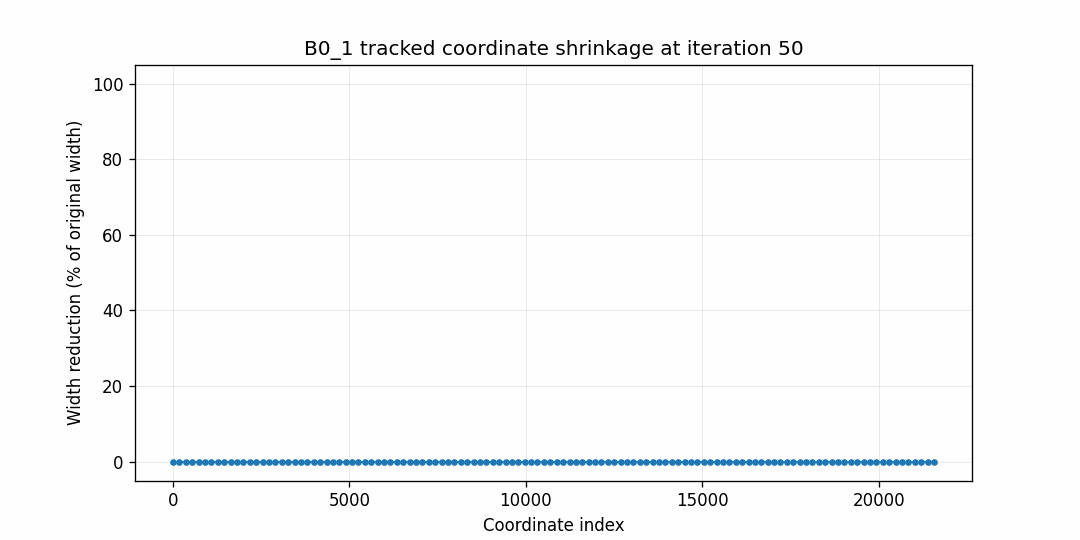

/Users/alexanderyordanov/Library/Mobile Documents/com~apple~CloudDocs/Documents/Work/GATE/Conjugate Gradient/cg-hyperbox-simulations/system_plate/B0_1_width_shrinkage_through_iter_500.gif

Saved 10 forward frames to system_plate/B0_2_width_shrinkage_through_iter_500.gif


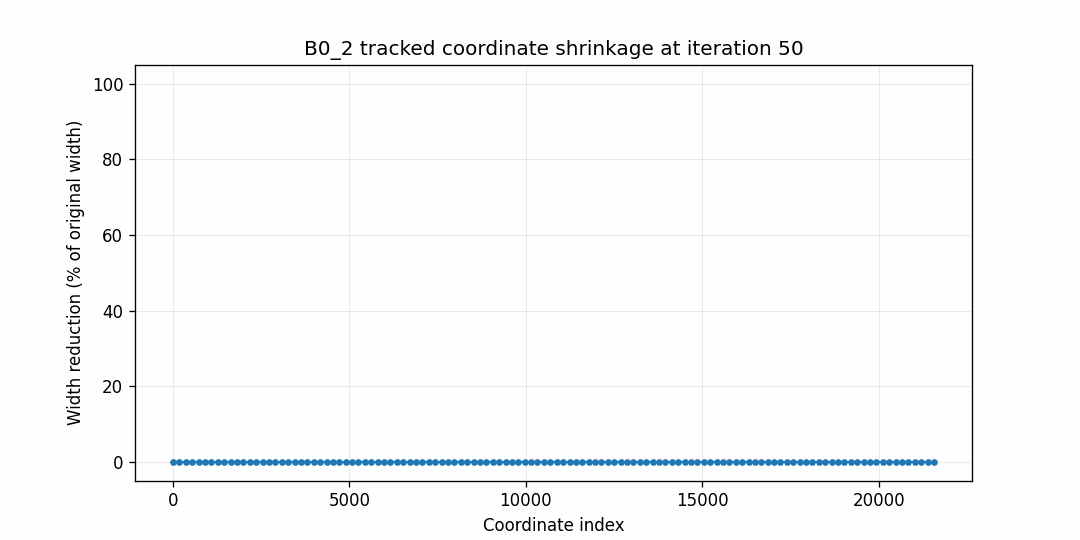

/Users/alexanderyordanov/Library/Mobile Documents/com~apple~CloudDocs/Documents/Work/GATE/Conjugate Gradient/cg-hyperbox-simulations/system_plate/B0_2_width_shrinkage_through_iter_500.gif

In [ ]:
GIF_MAX_ITERATION = 500
GIF_FPS = 5
GIF_DPI = 120


def export_shrinkage_gif(result):
    box_name = result["box_name"]
    tracked_indices = result["tracked_indices"]
    box_snapshot_iterations = result["box_snapshot_iterations"]
    tracked_shrinkage_pct = shrinkage_data(result)

    gif_frame_indices = np.flatnonzero(box_snapshot_iterations <= GIF_MAX_ITERATION)
    if len(gif_frame_indices) == 0:
        raise ValueError(f"No snapshots are available through iteration {GIF_MAX_ITERATION}.")

    gif_last_iteration = int(box_snapshot_iterations[gif_frame_indices[-1]])
    gif_path = base_dir / f"{box_name}_width_shrinkage_through_iter_{gif_last_iteration}.gif"

    finite_shrinkage = tracked_shrinkage_pct[np.isfinite(tracked_shrinkage_pct)]
    y_min = min(0.0, np.nanmin(finite_shrinkage))
    y_max = max(100.0, np.nanmax(finite_shrinkage))
    y_pad = 0.05 * max(1.0, y_max - y_min)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    line, = ax.plot(
        tracked_indices,
        tracked_shrinkage_pct[gif_frame_indices[0]],
        marker="o",
        markersize=3,
        linewidth=1,
    )
    title = ax.set_title(
        f"{box_name} tracked coordinate shrinkage at iteration {box_snapshot_iterations[gif_frame_indices[0]]}"
    )
    ax.set_xlabel("Coordinate index")
    ax.set_ylabel("Width reduction (% of original width)")
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(alpha=0.25)

    def update_shrinkage_gif(frame):
        line.set_ydata(tracked_shrinkage_pct[frame])
        title.set_text(
            f"{box_name} tracked coordinate shrinkage at iteration {box_snapshot_iterations[frame]}"
        )
        return line, title

    animation = FuncAnimation(
        fig,
        update_shrinkage_gif,
        frames=gif_frame_indices,
        interval=200,
        blit=False,
        repeat=True,
    )
    animation.save(gif_path, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
    plt.close(fig)

    print(f"Saved {len(gif_frame_indices)} forward frames to {gif_path}")
    display(Image(filename=str(gif_path)))
    display(FileLink(str(gif_path)))


for result in box_results.values():
    export_shrinkage_gif(result)


## Bounds animations


In [ ]:
def make_bounds_animation(result):
    box_name = result["box_name"]
    tracked_indices = result["tracked_indices"]
    box_snapshot_iterations = result["box_snapshot_iterations"]
    tracked_boxes = result["minimized_tracked_boxes_by_iteration"]
    tracked_lower = tracked_boxes[:, :, 0]
    tracked_upper = tracked_boxes[:, :, 1]
    original_lower = result["initial_lower"]
    original_upper = result["initial_upper"]

    finite_bounds = np.concatenate([
        tracked_lower[np.isfinite(tracked_lower)],
        tracked_upper[np.isfinite(tracked_upper)],
        original_lower[np.isfinite(original_lower)],
        original_upper[np.isfinite(original_upper)],
    ])
    y_min = np.nanmin(finite_bounds)
    y_max = np.nanmax(finite_bounds)
    y_pad = 0.05 * max(1.0, y_max - y_min)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(
        tracked_indices,
        original_lower,
        color="0.35",
        linestyle="--",
        linewidth=1,
        label="original lower",
    )
    ax.plot(
        tracked_indices,
        original_upper,
        color="0.35",
        linestyle=":",
        linewidth=1,
        label="original upper",
    )
    lower_line, = ax.plot(
        tracked_indices,
        tracked_lower[0],
        color="tab:blue",
        marker="o",
        markersize=3,
        linewidth=1,
        label="minimized lower",
    )
    upper_line, = ax.plot(
        tracked_indices,
        tracked_upper[0],
        color="tab:orange",
        marker="o",
        markersize=3,
        linewidth=1,
        label="minimized upper",
    )
    title = ax.set_title(f"{box_name} tracked bounds at iteration {box_snapshot_iterations[0]}")
    ax.set_xlabel("Coordinate index")
    ax.set_ylabel("Coordinate bound")
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    def update_bounds(frame):
        lower_line.set_ydata(tracked_lower[frame])
        upper_line.set_ydata(tracked_upper[frame])
        title.set_text(f"{box_name} tracked bounds at iteration {box_snapshot_iterations[frame]}")
        return lower_line, upper_line, title

    animation = FuncAnimation(
        fig,
        update_bounds,
        frames=len(box_snapshot_iterations),
        interval=200,
        blit=False,
    )
    plt.close(fig)
    return animation


for result in box_results.values():
    display(HTML(make_bounds_animation(result).to_jshtml()))


## Bounds GIF export


Saved 10 forward frames to system_plate/B0_1_bounds_through_iter_500.gif


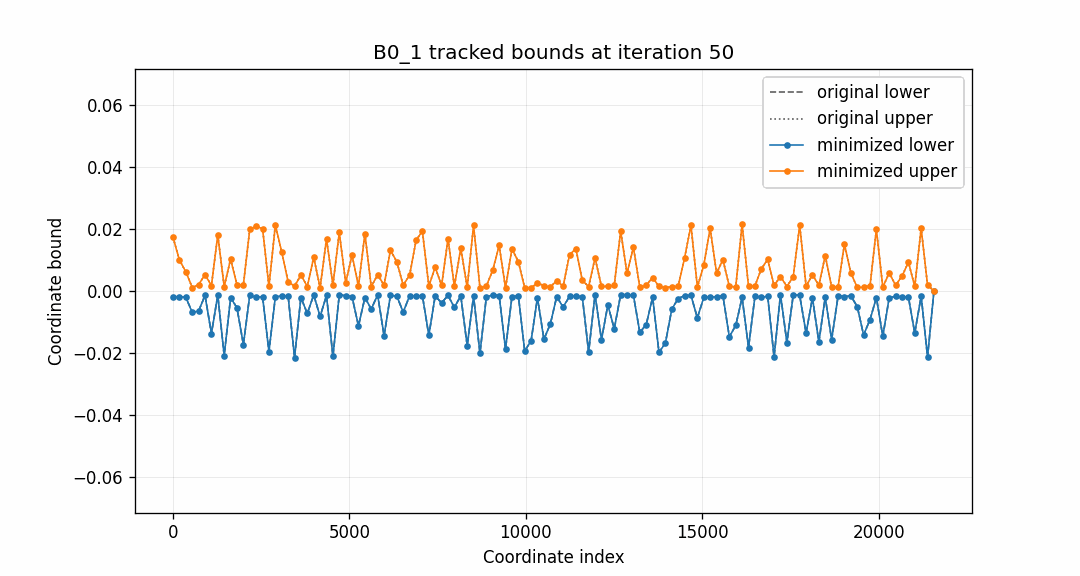

/Users/alexanderyordanov/Library/Mobile Documents/com~apple~CloudDocs/Documents/Work/GATE/Conjugate Gradient/cg-hyperbox-simulations/system_plate/B0_1_bounds_through_iter_500.gif

Saved 10 forward frames to system_plate/B0_2_bounds_through_iter_500.gif


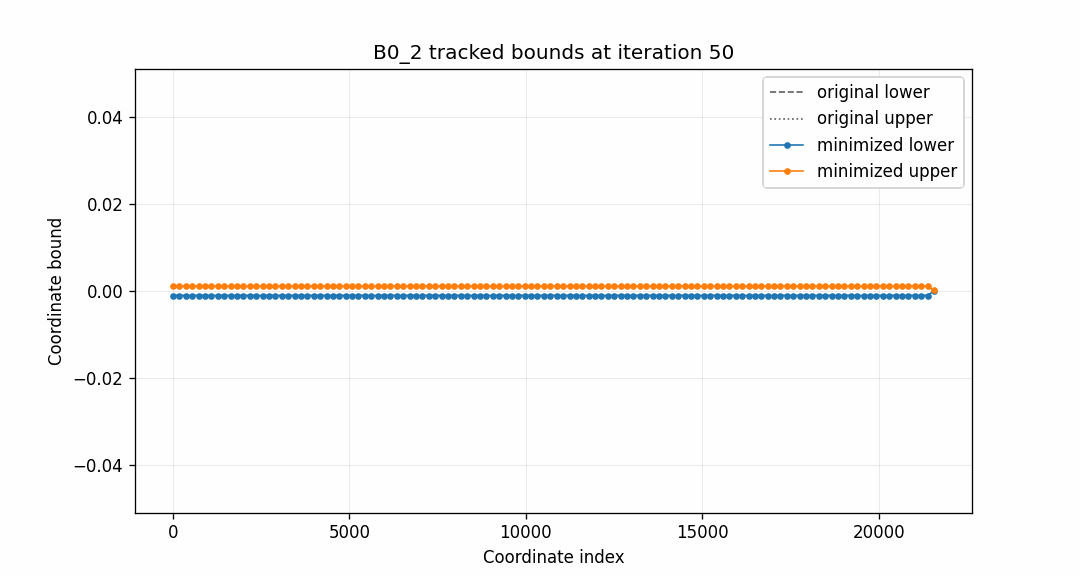

/Users/alexanderyordanov/Library/Mobile Documents/com~apple~CloudDocs/Documents/Work/GATE/Conjugate Gradient/cg-hyperbox-simulations/system_plate/B0_2_bounds_through_iter_500.gif

In [ ]:
def export_bounds_gif(result):
    box_name = result["box_name"]
    tracked_indices = result["tracked_indices"]
    box_snapshot_iterations = result["box_snapshot_iterations"]
    tracked_boxes = result["minimized_tracked_boxes_by_iteration"]
    tracked_lower = tracked_boxes[:, :, 0]
    tracked_upper = tracked_boxes[:, :, 1]
    original_lower = result["initial_lower"]
    original_upper = result["initial_upper"]

    gif_frame_indices = np.flatnonzero(box_snapshot_iterations <= GIF_MAX_ITERATION)
    if len(gif_frame_indices) == 0:
        raise ValueError(f"No snapshots are available through iteration {GIF_MAX_ITERATION}.")

    gif_last_iteration = int(box_snapshot_iterations[gif_frame_indices[-1]])
    gif_path = base_dir / f"{box_name}_bounds_through_iter_{gif_last_iteration}.gif"

    finite_bounds = np.concatenate([
        tracked_lower[np.isfinite(tracked_lower)],
        tracked_upper[np.isfinite(tracked_upper)],
        original_lower[np.isfinite(original_lower)],
        original_upper[np.isfinite(original_upper)],
    ])
    y_min = np.nanmin(finite_bounds)
    y_max = np.nanmax(finite_bounds)
    y_pad = 0.05 * max(1.0, y_max - y_min)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(
        tracked_indices,
        original_lower,
        color="0.35",
        linestyle="--",
        linewidth=1,
        label="original lower",
    )
    ax.plot(
        tracked_indices,
        original_upper,
        color="0.35",
        linestyle=":",
        linewidth=1,
        label="original upper",
    )
    lower_line, = ax.plot(
        tracked_indices,
        tracked_lower[gif_frame_indices[0]],
        color="tab:blue",
        marker="o",
        markersize=3,
        linewidth=1,
        label="minimized lower",
    )
    upper_line, = ax.plot(
        tracked_indices,
        tracked_upper[gif_frame_indices[0]],
        color="tab:orange",
        marker="o",
        markersize=3,
        linewidth=1,
        label="minimized upper",
    )
    title = ax.set_title(
        f"{box_name} tracked bounds at iteration {box_snapshot_iterations[gif_frame_indices[0]]}"
    )
    ax.set_xlabel("Coordinate index")
    ax.set_ylabel("Coordinate bound")
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    def update_bounds_gif(frame):
        lower_line.set_ydata(tracked_lower[frame])
        upper_line.set_ydata(tracked_upper[frame])
        title.set_text(f"{box_name} tracked bounds at iteration {box_snapshot_iterations[frame]}")
        return lower_line, upper_line, title

    animation = FuncAnimation(
        fig,
        update_bounds_gif,
        frames=gif_frame_indices,
        interval=200,
        blit=False,
        repeat=True,
    )
    animation.save(gif_path, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
    plt.close(fig)

    print(f"Saved {len(gif_frame_indices)} forward frames to {gif_path}")
    display(Image(filename=str(gif_path)))
    display(FileLink(str(gif_path)))


for result in box_results.values():
    export_bounds_gif(result)
